# Exploratory Data Analysis on India's COVID-19 Data

**Goal:** Explore state-wise trends, recovery/death rates, and vaccination progress in India's COVID-19 pandemic, using Pandas, NumPy, and Matplotlib/Seaborn.

**Data sources (loaded live, no manual download needed):**
- **Case data:** [imdevskp/covid-19-india-data](https://github.com/imdevskp/covid-19-india-data) — daily state-wise confirmed/recovered/death counts (30 Jan 2020 – 6 Aug 2020, India's first wave).
- **Vaccination data:** [Our World in Data (OWID)](https://github.com/owid/covid-19-data) — India's national vaccination totals (15 Jan 2021 onward).

**Workflow:** Load → Inspect → Clean → Explore (`groupby`/`pivot_table`) → Visualise (12 charts) → Summarise findings.

> **Note on the data window:** the case dataset covers only the first wave (through Aug 2020), before vaccines existed. The vaccination dataset picks up separately from Jan 2021. Both are treated as two connected parts of the same story.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

print("Ready.")

Ready.


## 1. Load the Data

Both CSVs are read straight from their public GitHub URLs with `pd.read_csv()`.

In [2]:
cases = pd.read_csv(
    "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"
)
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/country_data/India.csv"
)

print("Cases shape:", cases.shape)
print("Vaccination shape:", vax.shape)
cases.head()

Cases shape: (4692, 10)
Vaccination shape: (1250, 8)


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


## 2. Inspect Before Touching Anything

Always check shape, dtypes and missing values first — it tells you exactly what cleaning is needed.

In [3]:
cases.dtypes

Date                             str
Name of State / UT               str
Latitude                     float64
Longitude                    float64
Total Confirmed cases        float64
Death                            str
Cured/Discharged/Migrated    float64
New cases                      int64
New deaths                     int64
New recovered                  int64
dtype: object

In [4]:
cases.isna().sum()

Date                         0
Name of State / UT           0
Latitude                     0
Longitude                    0
Total Confirmed cases        0
Death                        0
Cured/Discharged/Migrated    0
New cases                    0
New deaths                   0
New recovered                0
dtype: int64

In [5]:
print("Number of unique state/UT names:", cases["Name of State / UT"].nunique())
sorted(cases["Name of State / UT"].unique())

Number of unique state/UT names: 40


['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Telangana***',
 'Telengana',
 'Tripura',
 'Union Territory of Chandigarh',
 'Union Territory of Jammu and Kashmir',
 'Union Territory of Ladakh',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

Two problems jump out immediately:

1. **`Death` is stored as text**, not a number — likely stray characters somewhere in the column.
2. **The same state appears under multiple spellings** — `Telangana`, `Telengana`, `Telangana***` are all the same state, and a few Union Territories are listed twice (once plainly, once with a "Union Territory of ..." prefix).

We fix both before doing any analysis, never after — cleaning after a `groupby` would leave earlier charts silently wrong.

## 3. Clean the Data

In [6]:
# Rename to clean, snake_case column names
cases.columns = [
    "date", "state", "lat", "long", "confirmed",
    "deaths", "cured", "new_cases", "new_deaths", "new_recovered",
]

# Fix data types
cases["date"] = pd.to_datetime(cases["date"])
cases["deaths"] = pd.to_numeric(cases["deaths"], errors="coerce").fillna(0).astype(int)
cases["confirmed"] = cases["confirmed"].astype(int)
cases["cured"] = cases["cured"].astype(int)

# Fix inconsistent state names
name_fix = {
    "Telangana***": "Telangana",
    "Telengana": "Telangana",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
    "Union Territory of Chandigarh": "Chandigarh",
}
cases["state"] = cases["state"].replace(name_fix)

# Drop any exact duplicate (date, state) rows
cases = cases.drop_duplicates(subset=["date", "state"]).sort_values(["state", "date"]).reset_index(drop=True)

# Derived column: active cases = confirmed - deaths - recovered
cases["active"] = cases["confirmed"] - cases["deaths"] - cases["cured"]
cases["month"] = cases["date"].dt.strftime("%Y-%m")

print("Clean state count:", cases["state"].nunique())
cases.dtypes

Clean state count: 35


date             datetime64[us]
state                       str
lat                     float64
long                    float64
confirmed                 int64
deaths                    int64
cured                     int64
new_cases                 int64
new_deaths                int64
new_recovered             int64
active                    int64
month                       str
dtype: object

In [7]:
cases.isna().sum().sum()   # should be 0 -- fully clean now

np.int64(0)

## 4. National-Level Summary (`groupby`)

We also add a **7-day rolling average** of daily new cases here — useful for smoothing out day-to-day reporting noise, something the original day-by-day numbers alone don't show clearly.

In [8]:
national = cases.groupby("date", as_index=False)[["confirmed", "deaths", "cured"]].sum()
national["recovery_rate"] = (national["cured"] / national["confirmed"] * 100).round(2)
national["death_rate"] = (national["deaths"] / national["confirmed"] * 100).round(2)
national["new_confirmed"] = national["confirmed"].diff().fillna(national["confirmed"])
national["new_confirmed_7d_avg"] = national["new_confirmed"].rolling(7).mean()
national["month"] = national["date"].dt.strftime("%Y-%m")

national.tail()

,date,confirmed,deaths,cured,recovery_rate,death_rate,new_confirmed,new_confirmed_7d_avg,month
181,2020-08-02,1750723,37364,1145629,65.44,2.13,54735.0,52171.571429,2020-08
182,2020-08-03,1803695,38135,1186203,65.77,2.11,52972.0,60994.285714,2020-08
183,2020-08-04,1855745,38938,1230509,66.31,2.10,52050.0,53227.000000,2020-08
184,2020-08-05,1908254,39795,1282215,67.19,2.09,52509.0,53797.857143,2020-08
185,2020-08-06,1964536,40699,1328336,67.62,2.07,56282.0,54392.000000,2020-08


In [9]:
latest_date = cases["date"].max()
latest_row = national.iloc[-1]

print(f"As of {latest_date.date()}:")
print(f"  Total confirmed : {latest_row['confirmed']:,}")
print(f"  Total recovered : {latest_row['cured']:,}")
print(f"  Total deaths    : {latest_row['deaths']:,}")
print(f"  Recovery rate   : {latest_row['recovery_rate']}%")
print(f"  Death rate      : {latest_row['death_rate']}%")

As of 2020-08-06:
  Total confirmed : 1,964,536
  Total recovered : 1,328,336
  Total deaths    : 40,699
  Recovery rate   : 67.62%
  Death rate      : 2.07%


## 5. State-Wise Snapshot (latest date)

In [10]:
latest = cases[cases["date"] == latest_date].copy()
latest["recovery_rate"] = (latest["cured"] / latest["confirmed"] * 100).round(2)
latest["death_rate"] = (latest["deaths"] / latest["confirmed"] * 100).round(2)
latest = latest.sort_values("confirmed", ascending=False).reset_index(drop=True)

top10 = latest.head(10)
top10[["state", "confirmed", "deaths", "cured", "recovery_rate", "death_rate"]]

,state,confirmed,deaths,cured,recovery_rate,death_rate
0,Maharashtra,468265,16476,305521,65.25,3.52
1,Tamil Nadu,273460,4461,214815,78.55,1.63
2,Andhra Pradesh,186461,1681,104354,55.97,0.90
3,Karnataka,151449,2804,74679,49.31,1.85
4,Delhi,140232,4044,126116,89.93,2.88
5,Uttar Pradesh,104388,1857,60558,58.01,1.78
6,West Bengal,83800,1846,58962,70.36,2.20
7,Telangana,73050,589,52103,71.33,0.81
8,Gujarat,66669,2556,49433,74.15,3.83
9,Bihar,64770,355,42414,65.48,0.55


`pivot_table`: confirmed cases by state and month, so we can see when each state's outbreak accelerated.

In [11]:
month_pivot = cases[cases["state"].isin(top10["state"].head(5))].pivot_table(
    values="new_cases", index="state", columns="month", aggfunc="sum", fill_value=0
)
month_pivot

month,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08
state,,,,,,
Andhra Pradesh,39,1292,2237,10322,116666,55904
Delhi,96,3342,15110,66612,49242,5829
Karnataka,82,452,2387,11373,104337,32817
Maharashtra,218,9699,55253,104715,241915,56467
Tamil Nadu,73,2088,19022,65040,153754,33482


## 6. Visualisations (12 charts)

We work through national trends, state comparisons, and relationships between metrics, using both Matplotlib and Seaborn.

### Chart 1 — National cumulative outcomes (stacked area)

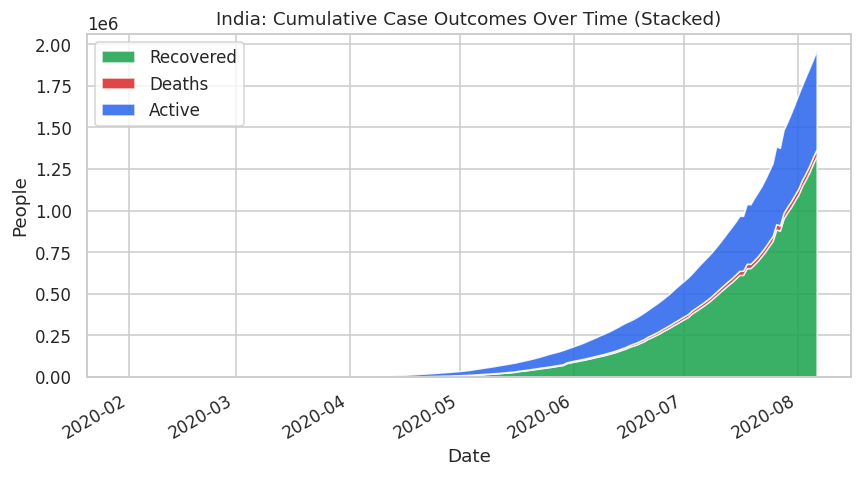

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
active_series = national["confirmed"] - national["cured"] - national["deaths"]
ax.stackplot(
    national["date"], national["cured"], national["deaths"], active_series,
    labels=["Recovered", "Deaths", "Active"],
    colors=["#16a34a", "#dc2626", "#2563eb"], alpha=0.85,
)
ax.set_title("India: Cumulative Case Outcomes Over Time (Stacked)")
ax.set_xlabel("Date"); ax.set_ylabel("People")
ax.legend(loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Chart 2 — Daily new confirmed cases, with 7-day rolling average

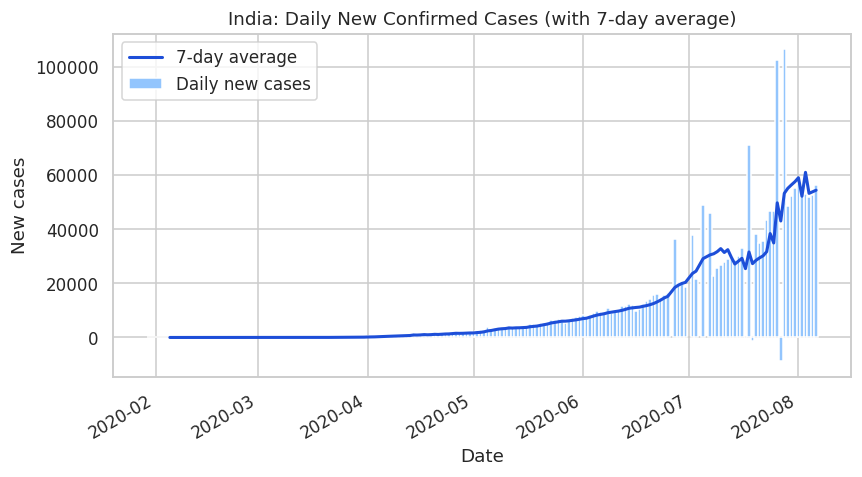

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(national["date"], national["new_confirmed"], color="#93c5fd", width=1.0, label="Daily new cases")
ax.plot(national["date"], national["new_confirmed_7d_avg"], color="#1d4ed8", lw=2, label="7-day average")
ax.set_title("India: Daily New Confirmed Cases (with 7-day average)")
ax.set_xlabel("Date"); ax.set_ylabel("New cases")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Chart 3 — Top 10 states: confirmed cases vs deaths (grouped bar)

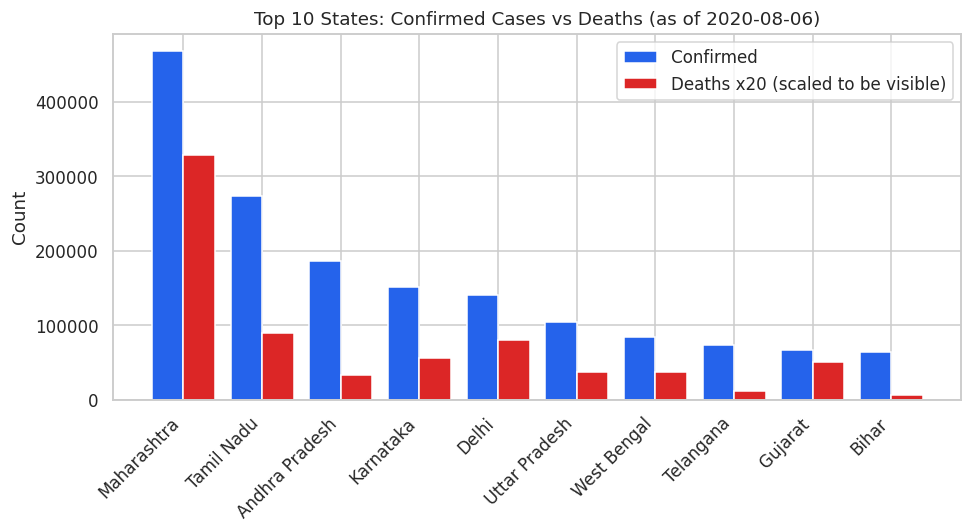

In [14]:
x = np.arange(len(top10))
width = 0.4
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, top10["confirmed"], width, label="Confirmed", color="#2563eb")
ax.bar(x + width/2, top10["deaths"] * 20, width, label="Deaths x20 (scaled to be visible)", color="#dc2626")
ax.set_xticks(x); ax.set_xticklabels(top10["state"], rotation=45, ha="right")
ax.set_title(f"Top 10 States: Confirmed Cases vs Deaths (as of {latest_date.date()})")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

### Chart 4 — Death rate of the 10 worst-hit states

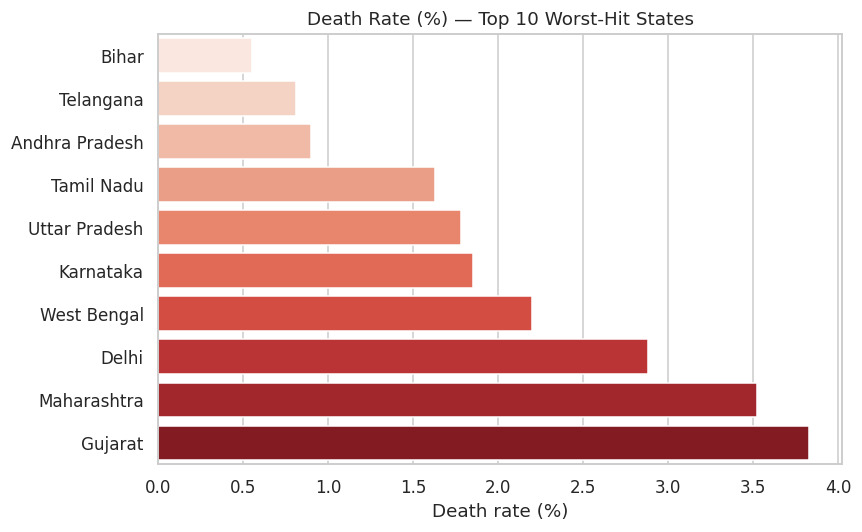

In [15]:
top10_sorted_dr = top10.sort_values("death_rate")
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10_sorted_dr, y="state", x="death_rate", hue="state", palette="Reds", legend=False, ax=ax)
ax.set_title("Death Rate (%) — Top 10 Worst-Hit States")
ax.set_xlabel("Death rate (%)"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Chart 5 — Confirmed-case trend for the top 5 states (log scale)

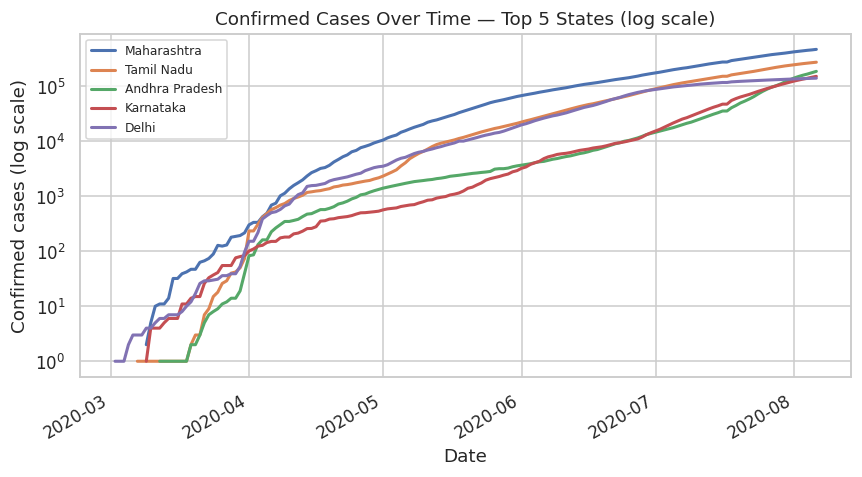

In [16]:
top5_states = top10["state"].head(5).tolist()

fig, ax = plt.subplots(figsize=(8, 4.5))
for s in top5_states:
    sub = cases[cases["state"] == s]
    ax.plot(sub["date"], sub["confirmed"].clip(lower=1), label=s, lw=2)
ax.set_yscale("log")
ax.set_title("Confirmed Cases Over Time — Top 5 States (log scale)")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases (log scale)")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Chart 6 — Share of national cases by state (donut)

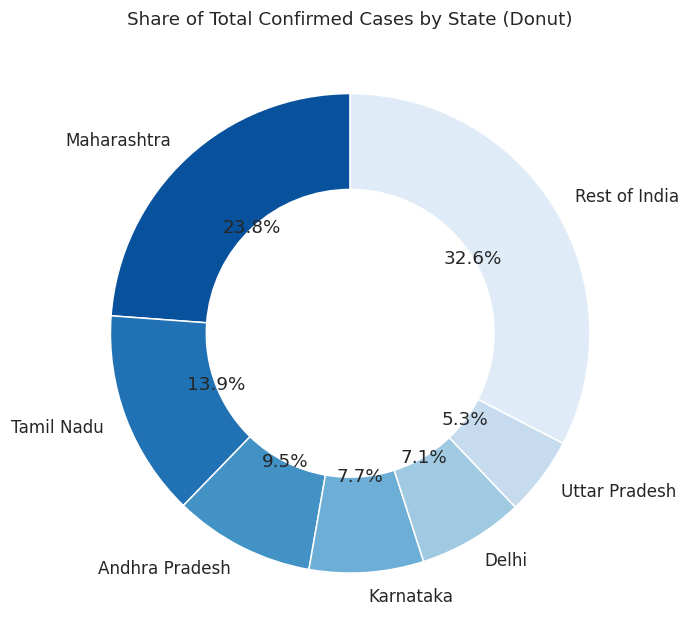

In [17]:
top6 = latest.nlargest(6, "confirmed")[["state", "confirmed"]]
others = latest["confirmed"].sum() - top6["confirmed"].sum()
pie_labels = top6["state"].tolist() + ["Rest of India"]
pie_values = top6["confirmed"].tolist() + [others]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(pie_values, labels=pie_labels, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("Blues_r", 7), wedgeprops=dict(width=0.4))
ax.set_title("Share of Total Confirmed Cases by State (Donut)")
plt.tight_layout()
plt.show()

### Chart 7 — National death-rate trend

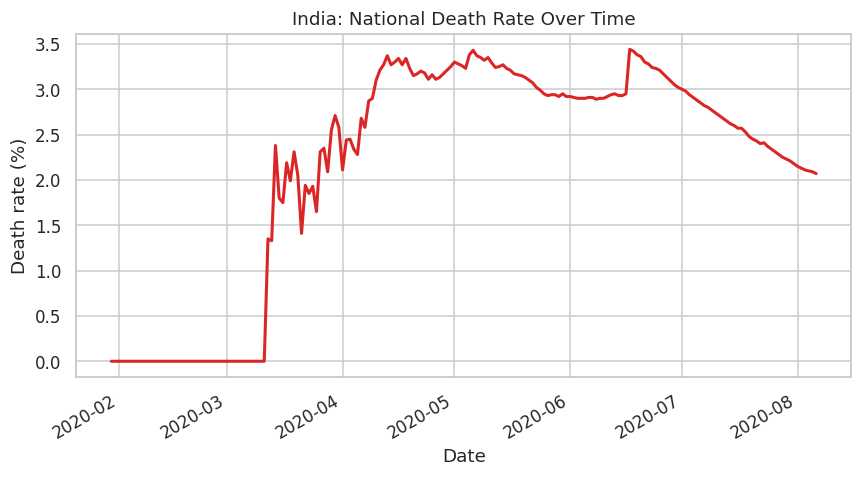

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["death_rate"], color="#dc2626", lw=2)
ax.set_title("India: National Death Rate Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Death rate (%)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Chart 8 — Active cases vs confirmed cases, by state (color = recovery rate)

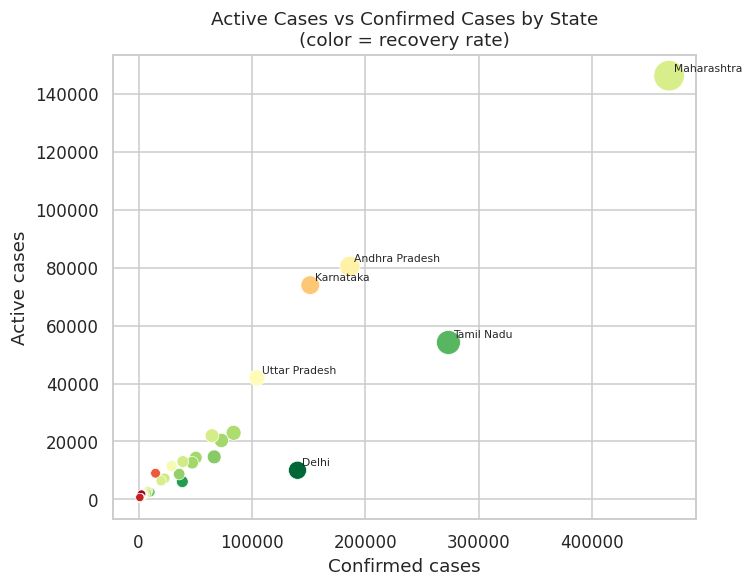

In [19]:
sizeable = latest[latest["confirmed"] >= 1000]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=sizeable, x="confirmed", y="active", hue="recovery_rate",
                 palette="RdYlGn", size="confirmed", sizes=(30, 400), legend=False, ax=ax)
for _, r in sizeable.nlargest(6, "confirmed").iterrows():
    ax.annotate(r["state"], (r["confirmed"], r["active"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_title("Active Cases vs Confirmed Cases by State\n(color = recovery rate)")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("Active cases")
plt.tight_layout()
plt.show()

### Chart 9 — Correlation heatmap of national metrics

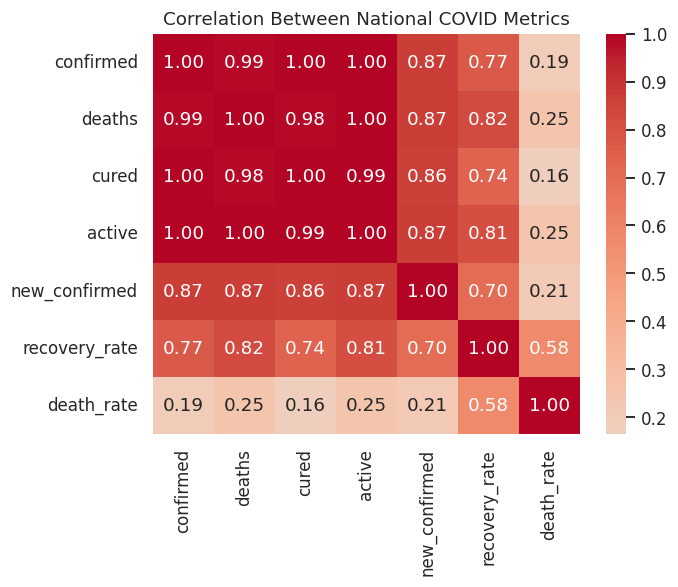

In [20]:
corr_cols = ["confirmed", "deaths", "cured", "active", "new_confirmed", "recovery_rate", "death_rate"]
corr = national.assign(active=national["confirmed"] - national["cured"] - national["deaths"])[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between National COVID Metrics")
plt.tight_layout()
plt.show()

### Chart 10 — Spread of daily new cases, by month (violin plot)

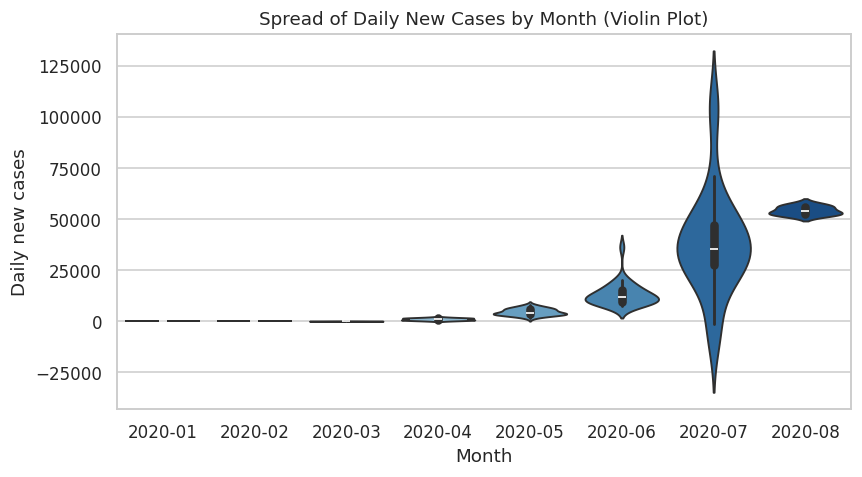

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(data=national, x="month", y="new_confirmed", hue="month", palette="Blues", legend=False, ax=ax)
ax.set_title("Spread of Daily New Cases by Month (Violin Plot)")
ax.set_xlabel("Month"); ax.set_ylabel("Daily new cases")
plt.tight_layout()
plt.show()

### Chart 11 — India's vaccination progress (cumulative + daily doses)

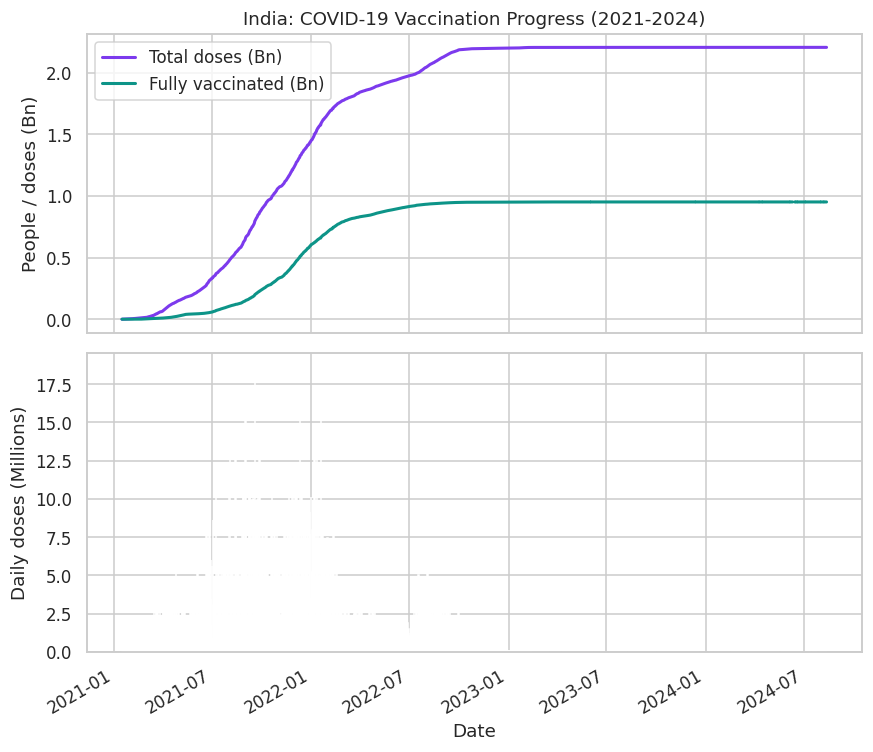

In [22]:
vax["date"] = pd.to_datetime(vax["date"])
vax["daily_doses"] = vax["total_vaccinations"].diff()

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
axes[0].plot(vax["date"], vax["total_vaccinations"] / 1e9, label="Total doses (Bn)", color="#7c3aed", lw=2)
axes[0].plot(vax["date"], vax["people_fully_vaccinated"] / 1e9, label="Fully vaccinated (Bn)", color="#0d9488", lw=2)
axes[0].set_ylabel("People / doses (Bn)")
axes[0].legend()
axes[0].set_title("India: COVID-19 Vaccination Progress (2021-2024)")
axes[1].bar(vax["date"], vax["daily_doses"] / 1e6, color="#a78bfa", width=1.0)
axes[1].set_ylabel("Daily doses (Millions)"); axes[1].set_xlabel("Date")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Chart 12 — The 10 least-affected states/UTs

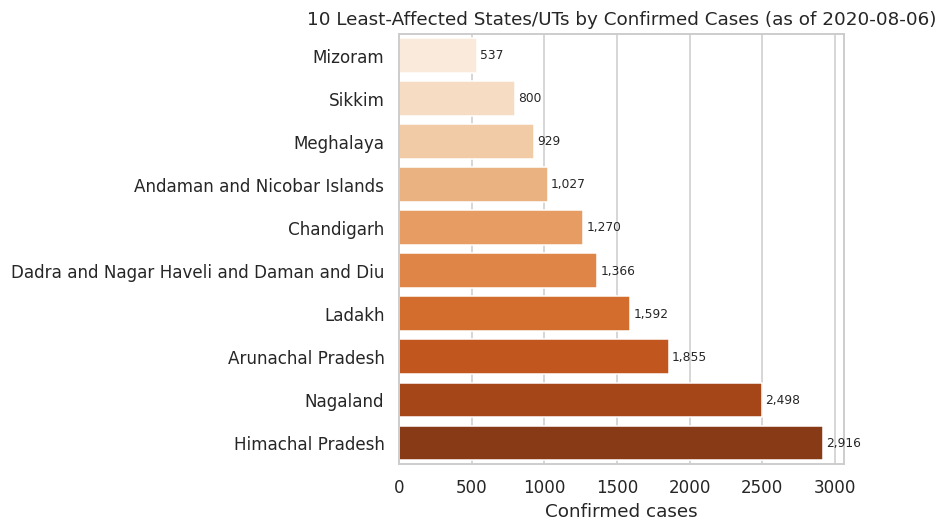

In [23]:
bottom10 = latest[latest["confirmed"] > 0].nsmallest(10, "confirmed")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=bottom10, y="state", x="confirmed", hue="state", palette="Oranges", legend=False, ax=ax)
for i, v in enumerate(bottom10["confirmed"]):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=8)
ax.set_title(f"10 Least-Affected States/UTs by Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 7. Save the Cleaned Dataset

Saving the cleaned table so it can be reused without repeating the cleaning steps.

In [24]:
cases.to_csv("cleaned_covid_india.csv", index=False)
print("Saved cleaned_covid_india.csv —", cases.shape[0], "rows.")

Saved cleaned_covid_india.csv — 4692 rows.


## 8. Written Summary

**Coverage.** The dataset tracks 35 states/UTs (after cleaning up duplicate spellings) across 186 days, from 30 January 2020 to 6 August 2020 — India's first COVID-19 wave.

**National picture.** By the end of the data window, India had recorded roughly 19.6 lakh (1.96 million) confirmed cases, about 13.3 lakh recoveries, and around 40,700 deaths — a national recovery rate near 68% and a death rate near 2.1%. Daily new cases were still climbing at the end of the window (peaking above 100,000 in a single day in late July 2020), so the first wave had not yet crested by the point this dataset ends.

**State-wise concentration.** The outbreak was heavily concentrated: Maharashtra alone accounted for close to a quarter of all national cases, with Tamil Nadu, Andhra Pradesh, Karnataka, and Delhi rounding out the top five. Together, the top 6 states held roughly two-thirds of total cases — the pandemic was never evenly spread across India.

**Recovery and death rates varied a lot by state.** Delhi stood out with a recovery rate near 90%, while Karnataka was still under 50% recovered at this snapshot — likely because Karnataka's outbreak was comparatively newer/faster-growing. Among the worst-hit states, Gujarat had the highest death rate (~3.8%), well above the national average, while Bihar and Telangana had rates under 1%.

**Vaccination (a later chapter of the same story).** India's vaccination drive began in January 2021, months after this case dataset ends. By mid-2024, national records show over 2.2 billion vaccine doses administered and 950+ million people fully vaccinated.

**Caveats.** This is state-bulletin-sourced case data — it inherits any inconsistencies in how individual states reported numbers (hence the name-spelling and text-formatted `Death` column issues fixed above). Recovery/death rates here are simple ratios of cumulative totals, not adjusted for reporting lag, so they should be read as directional trends rather than precise clinical outcome rates.

**Ideas for further analysis:** bring in state population data to compute per-capita rates; pull in district-level data for a finer-grained picture; extend the case time series past August 2020 to see the second wave.
